## Imports

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

import warnings
warnings.filterwarnings("ignore")

## Transformations

Ici, nous allons redéfinir la taille des images, les normaliser, les transformer en tenseur (pour pytorch). Pour l'entraînement, nous allons leur faire subir des rotations, des variations de luminosité etc. pour augmenter les données.

In [35]:

# Transformations pour l'entraînement (avec augmentation de données)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),                    
    transforms.RandomHorizontalFlip(p=0.5),          
    transforms.RandomRotation(15),                   
    transforms.ColorJitter(brightness=0.2,            
                          contrast=0.2,             
                          saturation=0.2),            
    transforms.ToTensor(),                           
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Transformations pour validation et test (sans augmentation)
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

## Chargement des données

In [3]:
full_dataset = ImageFolder('../data/')

print(f"Nombre total d'images: {len(full_dataset)}")
print(f"Nombre de classes: {len(full_dataset.classes)}")
print(f"Mapping classe->index: {full_dataset.class_to_idx}")


Nombre total d'images: 11945
Nombre de classes: 151
Mapping classe->index: {'Abra': 0, 'Aerodactyl': 1, 'Alakazam': 2, 'Arbok': 3, 'Arcanine': 4, 'Articuno': 5, 'Beedrill': 6, 'Bellsprout': 7, 'Blastoise': 8, 'Bulbasaur': 9, 'Butterfree': 10, 'Caterpie': 11, 'Chansey': 12, 'Charizard': 13, 'Charmander': 14, 'Charmeleon': 15, 'Clefable': 16, 'Clefairy': 17, 'Cloyster': 18, 'Cubone': 19, 'Dewgong': 20, 'Diglett': 21, 'Ditto': 22, 'Dodrio': 23, 'Doduo': 24, 'Dragonair': 25, 'Dragonite': 26, 'Dratini': 27, 'Drowzee': 28, 'Dugtrio': 29, 'Eevee': 30, 'Ekans': 31, 'Electabuzz': 32, 'Electrode': 33, 'Exeggcute': 34, 'Exeggutor': 35, 'Farfetchd': 36, 'Fearow': 37, 'Flareon': 38, 'Gastly': 39, 'Gengar': 40, 'Geodude': 41, 'Gloom': 42, 'Golbat': 43, 'Goldeen': 44, 'Golduck': 45, 'Golem': 46, 'Graveler': 47, 'Grimer': 48, 'Growlithe': 49, 'Gyarados': 50, 'Haunter': 51, 'Hitmonchan': 52, 'Hitmonlee': 53, 'Horsea': 54, 'Hypno': 55, 'Ivysaur': 56, 'Jigglypuff': 57, 'Jolteon': 58, 'Jynx': 59, 'Kabuto'

## Séparations des données en jeu de train/validation/test

In [37]:
# Extraire tous les indices et leurs labels
indices = list(range(len(full_dataset)))
labels = [full_dataset[i][1] for i in indices]

# Premier split: séparer 70% pour train, 30% pour val+test

train_idx, temp_idx = train_test_split(
    indices, 
    test_size=0.3,
    stratify=labels,
    random_state=42
)

# Extraire les labels du set temporaire pour le prochain split
temp_labels = [full_dataset[i][1] for i in temp_idx]

# Deuxième split: diviser les 30% restants en 15% validation et 15% test
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42
)

print(f"\nRépartition des données:")
print(f"Train: {len(train_idx)} images ({len(train_idx)/len(full_dataset)*100:.1f}%)")
print(f"Validation: {len(val_idx)} images ({len(val_idx)/len(full_dataset)*100:.1f}%)")
print(f"Test: {len(test_idx)} images ({len(test_idx)/len(full_dataset)*100:.1f}%)")


Répartition des données:
Train: 8361 images (70.0%)
Validation: 1792 images (15.0%)
Test: 1792 images (15.0%)


## Création des datasets ayant subis les transformations

In [38]:
# Cette classe permet d'appliquer des transformations différentes selon le dataset
class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform
    
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        # Récupérer le chemin de l'image et son label
        image_path, label = self.dataset.samples[self.indices[idx]]
        # Charger l'image
        image = Image.open(image_path).convert('RGB')
        # Appliquer les transformations
        if self.transform:
            image = self.transform(image)
        return image, label

# Créer les 3 datasets avec leurs transformations respectives
train_dataset = TransformedSubset(full_dataset, train_idx, train_transform)
val_dataset = TransformedSubset(full_dataset, val_idx, val_test_transform)
test_dataset = TransformedSubset(full_dataset, test_idx, val_test_transform)

# Créer les DataLoaders qui vont charger les données par batch
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

## Transfer learning avec EfficientNet-B0

In [39]:
def create_model(num_classes, freeze_base=True):
    
    model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
    
    if freeze_base:
        for param in model.parameters():
            param.requires_grad = False
    
    # Récupération des features
    num_features = model.classifier[1].in_features
    
    # Reconstruction du classifieur
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_features, num_classes)
    )
    
    return model

## Configuration de l'entraînement

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUtilisation de: {device}")

num_classes = len(full_dataset.classes)
# Créer le modèle et le déplacer sur le device
model = create_model(num_classes, freeze_base=True).to(device)

# Fonction de perte pour la classification
criterion = nn.CrossEntropyLoss()

# Optimiseur Adam avec learning rate de 0.001
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Scheduler pour réduire le learning rate si la validation stagne
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                  factor=0.5, patience=3)


Utilisation de: cuda


## Entraînement et validation

In [41]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

num_epochs = 50

# Paramètres pour le fine-tuning progressif
unfreeze_epoch = 10  # À partir de quelle epoch dégeler le modèle
fine_tuning_lr = 0.0001  # Learning rate réduit pour le fine-tuning

best_val_acc = 0.0
patience_counter = 0
early_stop_patience = 7  # Arrêter si pas d'amélioration après 7 epochs

for epoch in range(num_epochs):
    
    # Fine tuning progressif Dégeler le modèle après unfreeze_epoch
    if epoch == unfreeze_epoch and num_classes > 10:

        print(f"Epoch {epoch+1}: degel du modele pour le fine tuning")
        
        # Dégeler toutes les couches
        for param in model.parameters():
            param.requires_grad = True
        
        # Créer un nouvel optimiseur avec un learning rate plus petit
        if hasattr(model, 'fc'):
            optimizer = optim.Adam([
                {'params': model.fc.parameters(), 'lr': fine_tuning_lr * 10},
                {'params': [p for n, p in model.named_parameters() if 'fc' not in n], 'lr': fine_tuning_lr}
            ], weight_decay=1e-4)
        else:
            optimizer = optim.Adam(model.parameters(), lr=fine_tuning_lr, weight_decay=1e-4)
        
        # Réinitialiser le scheduler avec le nouvel optimiseur
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                          factor=0.5, patience=3)
        
        print(f"Modèle dégelé. Nouveau learning rate: {fine_tuning_lr}")
        print(f"Paramètres entraînables: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
        print("="*60 + "\n")
    
    # Entrainement
    model.train()  # Active le mode entraînement
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        # Déplacer les données sur le device (GPU ou CPU)
        images, labels = images.to(device), labels.to(device)
        
        # Réinitialiser les gradients
        optimizer.zero_grad()
        
        # Forward pass: calculer les prédictions
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass: calculer les gradients
        loss.backward()
        
        # Gradient clipping pour stabiliser l'entraînement lors du fine-tuning
        if epoch >= unfreeze_epoch:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Mettre à jour les poids
        optimizer.step()
        
        # Accumuler les statistiques
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
    
    # Calculer les métriques moyennes d'entraînement
    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    
    # Validation
    model.eval()  # Active le mode évaluation
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    # torch.no_grad() désactive le calcul des gradients (plus rapide et moins de mémoire)
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
    
    # Calculer les métriques moyennes de validation
    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_acc = 100 * correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)
    
    # Ajuster le learning rate si nécessaire
    scheduler.step(epoch_val_loss)
    
    # Early stopping: sauvegarder le meilleur modèle
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_acc': best_val_acc,
        }, 'best_model_first_gen.pth')

    else:
        patience_counter += 1
    
    # Afficher les résultats de l'epoch
    status = "Feature Extraction" if epoch < unfreeze_epoch else "Fine-Tuning"
    print(f"Epoch [{epoch+1}/{num_epochs}] {status} | Train - Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.2f}% | "
    f"Val - Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.2f}% (Best: {best_val_acc:.2f}%)")
   
    # Early stopping
    if patience_counter >= early_stop_patience:
        print(f"\nEarly stopping, pas d'amélioration depuis {early_stop_patience} epochs")
        print(f"Meilleure validation accuracy: {best_val_acc:.2f}%")
        break

Epoch [1/50] Feature Extraction | Train - Loss: 3.5587, Acc: 35.67% | Val - Loss: 2.4957, Acc: 61.05% (Best: 61.05%)
Epoch [2/50] Feature Extraction | Train - Loss: 1.8759, Acc: 69.02% | Val - Loss: 1.7613, Acc: 68.36% (Best: 68.36%)
Epoch [3/50] Feature Extraction | Train - Loss: 1.3399, Acc: 76.22% | Val - Loss: 1.4363, Acc: 71.76% (Best: 71.76%)
Epoch [4/50] Feature Extraction | Train - Loss: 1.0912, Acc: 79.05% | Val - Loss: 1.3180, Acc: 73.60% (Best: 73.60%)
Epoch [5/50] Feature Extraction | Train - Loss: 0.9294, Acc: 81.68% | Val - Loss: 1.2115, Acc: 72.54% (Best: 73.60%)
Epoch [6/50] Feature Extraction | Train - Loss: 0.8367, Acc: 82.51% | Val - Loss: 1.1396, Acc: 74.50% (Best: 74.50%)
Epoch [7/50] Feature Extraction | Train - Loss: 0.7594, Acc: 83.94% | Val - Loss: 1.0532, Acc: 75.67% (Best: 75.67%)
Epoch [8/50] Feature Extraction | Train - Loss: 0.6777, Acc: 85.72% | Val - Loss: 1.0855, Acc: 75.11% (Best: 75.67%)
Epoch [9/50] Feature Extraction | Train - Loss: 0.6229, Acc: 86.

## Test

In [42]:
print("\nÉvaluation finale sur le test set")
model.eval()
correct_test = 0
total_test = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

test_accuracy = 100 * correct_test / total_test
print(f'Accuracy sur le test set: {test_accuracy:.2f}%')


Évaluation finale sur le test set
Accuracy sur le test set: 94.70%


## Visualisation des courbes d'apprentissage


Courbes d'apprentissage sauvegardées dans 'learning_curves.png'


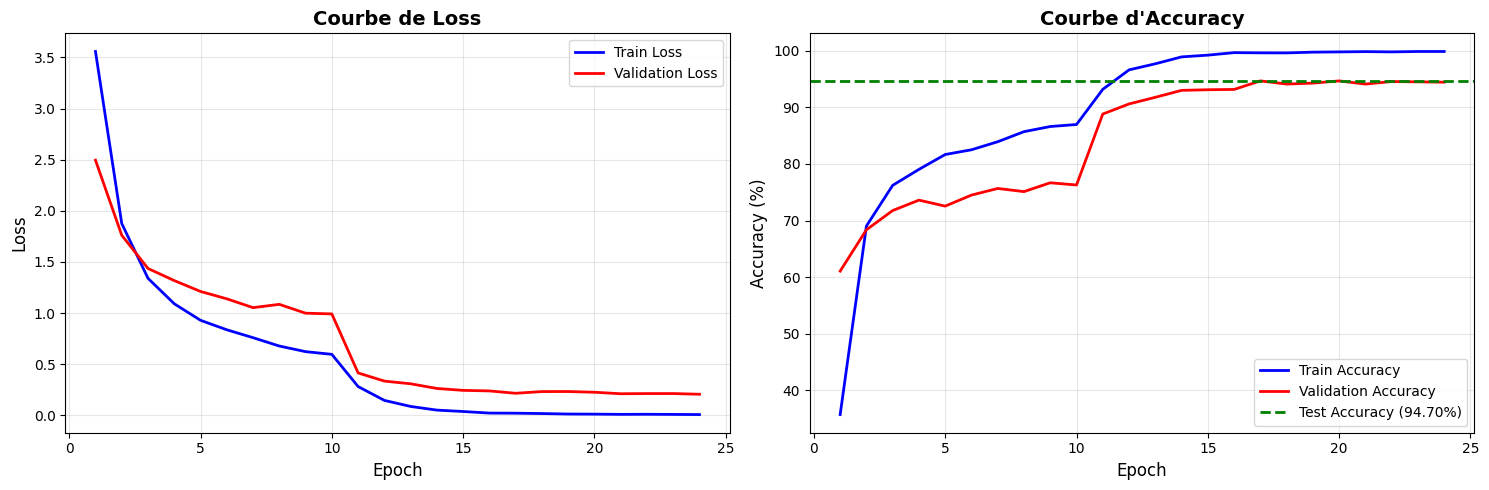

In [43]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Courbe de loss
ax1.plot(range(1, len(train_losses) + 1), train_losses, 'b-', label='Train Loss', linewidth=2)
ax1.plot(range(1, len(train_losses) + 1), val_losses, 'r-', label='Validation Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Courbe de Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Courbe d'accuracy
ax2.plot(range(1, len(train_losses) + 1), train_accuracies, 'b-', label='Train Accuracy', linewidth=2)
ax2.plot(range(1, len(train_losses) + 1), val_accuracies, 'r-', label='Validation Accuracy', linewidth=2)
ax2.axhline(y=test_accuracy, color='g', linestyle='--', label=f'Test Accuracy ({test_accuracy:.2f}%)', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Courbe d\'Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=300, bbox_inches='tight')
print("\nCourbes d'apprentissage sauvegardées dans 'learning_curves.png'")
plt.show()

On remarque un léger overfitting mais ce n'est pas dramatique au vu des bons résultats qu'on obtient.

## Sauvegarde du modèle

In [44]:
torch.save({
    'epoch': num_epochs,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses,
    'train_accuracies': train_accuracies,
    'val_accuracies': val_accuracies,
    'test_accuracy': test_accuracy,
}, 'model.pth')

print("Modèle sauvegardé comme 'model.pth'")


Modèle sauvegardé comme 'model.pth'


In [45]:
model.cpu()
model.eval()

example_input = torch.randn(1, 3, 224, 224)  
traced_model = torch.jit.trace(model, example_input)

traced_model.save("model_mobile.pt")

print("Modèle mobile sauvegardé comme 'model_mobile.pt'")

Modèle mobile sauvegardé comme 'model_mobile.pt'
